In [3]:
# =====================================
# Environment setup & imports
# =====================================
import os, sys, json, math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from argparse import ArgumentParser
from torch.utils.data import DataLoader, Dataset

# -------------------------------------
# Set base working directory
# -------------------------------------
base_path = r"C:\Users\engs2653\Desktop\Timeseries_fuction\src"

# Add base path and subfolders to sys.path for imports
sys.path.append(base_path)
sys.path.append(os.path.join(base_path, "datasets"))      

# -------------------------------------
# Import  modules
# -------------------------------------
from data_provider import data_provider  
from MemorylessJumpNet import MemorylessJumpNet     

# -------------------------------------
# Global reproducibility
# -------------------------------------
torch.manual_seed(42)
np.random.seed(42)

print("✅ Environment ready!")
print("Base folder:", base_path)
print("CUDA available:", torch.cuda.is_available())


✅ Environment ready!
Base folder: C:\Users\engs2653\Desktop\Timeseries_fuction
CUDA available: True


In [4]:
import os, json, torch, numpy as np
from argparse import ArgumentParser

# -----------------------------
# Dataset selection
# -----------------------------
dataset = "ETTm2"  # or ETTh1, ETTh2, etc.
pred_len = 96      # 192, 336, 720 also possible

# -----------------------------
# Paths
# -----------------------------
dataset_dir = os.path.join(base_path, "datasets")

torch.manual_seed(42)
np.random.seed(42)
parser = ArgumentParser()
args = parser.parse_known_args()[0]

args_path = os.path.join(dataset_dir, f"{dataset}.txt")
if not os.path.exists(args_path):
    raise FileNotFoundError(f"Missing args file: {args_path}")

with open(args_path, 'r') as f:
    args.__dict__ = json.load(f)

args.root_path = dataset_dir
args.data_path = dataset + ".csv"
args.seq_len = 96
args.pred_len = pred_len
args.batch_size = 4 if "ETT" in dataset else 32

print(f"Preparing data for {pred_len}-step predictions on the {dataset} dataset.")
torch.manual_seed(42)
np.random.seed(42)

data_set, data_loader = data_provider(args, flag='train')
validation_set, validation_loader = data_provider(args, flag='val')
test_set, test_loader = data_provider(args, flag='test')


Preparing data for 96-step predictions on the ETTm2 dataset.
train 34369
val 11425
test 11425


0
torch.Size([4, 96, 7]) torch.Size([4, 144, 7]) torch.Size([4, 96, 4]) torch.Size([4, 144, 4])
Min/Max: -3.4378790261018892 2.8966596001488423


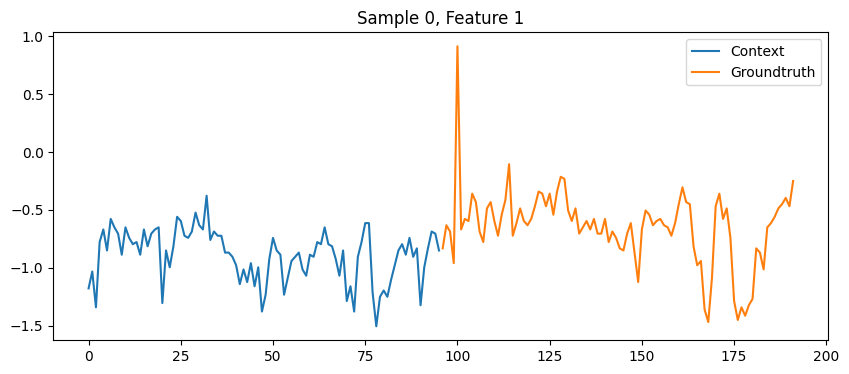

In [5]:
import matplotlib.pyplot as plt
import random as rd  

# Visualise some sampled data from the dataset
print(data_set)
print(data_loader)

for i, (batch_x, batch_y, batch_x_mark, batch_y_mark) in enumerate(data_loader):
    print(i)
    print(batch_x.shape, batch_y.shape, batch_x_mark.shape, batch_y_mark.shape)
    print("Min/Max:", torch.min(batch_x).item(), torch.max(batch_x).item())

    # Pick random sample and feature index
    ind = rd.randint(0, batch_x.shape[0] - 1)
    ind_2 = rd.randint(0, batch_x.shape[2] - 1)

    # Plot input context vs ground truth
    plt.figure(figsize=(10, 4))
    plt.plot(batch_x[ind, :, ind_2], label='Context')
    plt.plot(
        [batch_x.shape[1] + k for k in range(batch_y.shape[1] - 48)],
        batch_y[ind, 48:, ind_2],
        label='Groundtruth'
    )
    plt.legend()
    plt.title(f"Sample {i}, Feature {ind_2}")
    plt.show()

    break  # show only one batch


In [9]:
import os
import math
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd

# -------------------------
# Utility: infer steps per 24h from dataset name / args
# -------------------------
def infer_steps_per_day(args, dataset_name: str, default_L: int) -> int:
    if hasattr(args, "steps_per_day") and args.steps_per_day:
        return int(args.steps_per_day)
    d = (dataset_name or "").lower()
    if d.startswith("etth"):              return 24
    if d.startswith("ettm"):              return 96
    if d == "weather":                    return 96
    if d in ("electricity", "traffic"):   return 24
    if "exchange" in d:                   return 1
    return int(default_L)

# -------------------------
# Dataset (1-day blocks, D-day jump)
# -------------------------
class JumpSliceDataset(Dataset):
    def __init__(self, ts_tensor: torch.Tensor, L: int, NJ: int,
                 jump_stride_steps: int, start_stride: int = None):
        assert ts_tensor.ndim == 2, "ts_tensor must be [N, C]"
        self.ts = ts_tensor.float().contiguous()
        self.N, self.C = self.ts.shape
        self.L  = int(L)
        self.NJ = int(NJ)
        self.J  = int(jump_stride_steps)
        self.start_stride = int(start_stride if start_stride is not None else self.J)
        end_needed = self.NJ * self.J + self.L
        if self.N < end_needed:
            raise RuntimeError(f"Series too short: need >= {end_needed}, got {self.N}")
        self.starts = list(range(0, self.N - end_needed + 1, self.start_stride))

    def __len__(self): return len(self.starts)
    def __getitem__(self, idx):
        i = self.starts[idx]
        L, J, NJ = self.L, self.J, self.NJ
        x = self.ts[i : i + L]
        y = self.ts[i + NJ*J : i + NJ*J + L]
        return x, y

# -------------------------
# Use the paper's split objects
# -------------------------
def _extract_split_tensor(split_ds):
    for attr in ["data_x", "data", "raw_x", "raw"]:
        if hasattr(split_ds, attr):
            arr = getattr(split_ds, attr)
            if isinstance(arr, torch.Tensor):
                t = arr
            elif isinstance(arr, np.ndarray):
                t = torch.from_numpy(arr)
            else:
                continue
            if t.ndim == 3:
                t = t.reshape(-1, t.shape[-1])
            assert t.ndim == 2
            return t.float()
    if 'args' not in globals():
        raise RuntimeError("No tensor found on split_ds and no global args for fallback.")
    csv_path = os.path.join(args.root_path, args.data_path)
    df = pd.read_csv(csv_path)
    vals = df.iloc[:, 1:].values.astype(np.float32)
    t = torch.tensor(vals)
    b1 = getattr(split_ds, "border1", None)
    b2 = getattr(split_ds, "border2", None)
    return t[b1:b2] if (b1 is not None and b2 is not None) else t

# -------------------------
# Training loop (loss ONLY on target block)
# -------------------------
def train_one_jump_memoryless(
    NJ: int,
    jump_stride_steps: int,
    start_stride: int = None,
    save_prefix: str = None,
    debug_every: int = 1,
    epochs: int = 100,
    lr: float = 1e-3,
    alpha_smooth: float = 0.0,
    patience_max: int = 20
):
    assert 'args' in globals(), "This function expects global args."
    assert 'data_set' in globals() and 'validation_set' in globals(), "Expected splits."
    assert 'dataset' in globals(), "Expected global dataset."

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    L_day = infer_steps_per_day(args, dataset, default_L=int(getattr(args, "seq_len", 96)))
    if getattr(args, "seq_len", None) != L_day:
        print(f"[INFO] Overriding args.seq_len -> one-day L={L_day}")
    L = L_day

    ts_train = _extract_split_tensor(data_set)
    ts_val   = _extract_split_tensor(validation_set)

    train_ds = JumpSliceDataset(ts_train, L=L, NJ=NJ, jump_stride_steps=jump_stride_steps,
                                start_stride=(start_stride if start_stride is not None else jump_stride_steps))
    val_ds   = JumpSliceDataset(ts_val,   L=L, NJ=NJ, jump_stride_steps=jump_stride_steps,
                                start_stride=(start_stride if start_stride is not None else jump_stride_steps))

    pin_mem = torch.cuda.is_available()
    num_workers = 0
    train_loader = DataLoader(train_ds, batch_size=args.batch_size, shuffle=True,
                              drop_last=False, pin_memory=pin_mem, num_workers=num_workers)
    val_loader   = DataLoader(val_ds, batch_size=args.batch_size, shuffle=False,
                              drop_last=False, pin_memory=pin_mem, num_workers=num_workers)

    bx0, _ = next(iter(train_loader))
    C = bx0.shape[2]
    model = MemorylessJumpNet(C=C, L=L, d_model=256, depth=2, use_revin=True).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    mse = nn.MSELoss()

    def block_smooth_loss(yhat, y):
        dyhat = yhat[:, 1:, :] - yhat[:, :-1, :]
        dy    = y[:, 1:, :] - y[:, :-1, :]
        return nn.functional.mse_loss(dyhat, dy)

    best_val = float("inf")
    patience = 0

    # Create subfolder for checkpoints under the dataset directory
    dataset_name = globals().get("dataset", "data")
    data_dir = os.path.join(args.root_path, os.path.dirname(args.data_path))
    ckpt_dir = os.path.join(data_dir, f"checkpoints_{dataset_name}")
    os.makedirs(ckpt_dir, exist_ok=True)

    pred_len = int(getattr(args, "pred_len", L))
    save_path = os.path.join(ckpt_dir, f"{dataset_name}_PL{pred_len}_JD{jump_stride_steps}_NJ{NJ}.pt")

    for epoch in range(epochs):
        model.train()
        patience += 1
        tr_loss, nb = 0.0, 0

        for xLC, yLC in train_loader:
            xLC, yLC = xLC.to(device), yLC.to(device)
            pred = model(xLC)
            loss = mse(pred, yLC)
            if alpha_smooth > 0:
                loss += alpha_smooth * block_smooth_loss(pred, yLC)
            opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tr_loss += loss.item(); nb += 1

        tr_loss /= max(1, nb)
        model.eval()
        va_loss, nbv = 0.0, 0
        with torch.no_grad():
            for xLC, yLC in val_loader:
                xLC, yLC = xLC.to(device), yLC.to(device)
                pred = model(xLC)
                loss = mse(pred, yLC)
                if alpha_smooth > 0:
                    loss += alpha_smooth * block_smooth_loss(pred, yLC)
                va_loss += loss.item(); nbv += 1
        va_loss /= max(1, nbv)
        print(f"[NJ={NJ}] epoch {epoch}: train {tr_loss:.6f} | val {va_loss:.6f}")

        if va_loss < best_val:
            best_val = va_loss
            patience = 0
            torch.save(model.state_dict(), save_path)
            print(f"[NJ={NJ}] saved best model to {save_path}")
        if patience > patience_max:
            print(f"[NJ={NJ}] early stop at epoch {epoch}. Best val={best_val:.6f}")
            break

    return best_val, save_path

# -------------------------
# Driver
# -------------------------
def train_all_jumps(jumps=None, start_stride=None, save_prefix=None, **kwargs):
    assert 'args' in globals(), "Need global args."
    assert 'dataset' in globals(), "Need global dataset."
    steps_per_day = infer_steps_per_day(args, dataset, default_L=int(getattr(args, "seq_len", 96)))
    L_day = steps_per_day
    pred_len_steps = int(args.pred_len)
    K_train = math.ceil(pred_len_steps / steps_per_day)
    if jumps is None:
        jumps = list(range(1, K_train + 1))
    if start_stride is None:
        start_stride = steps_per_day
    print(f"[driver] dataset={dataset}, L={L_day}, pred_len={pred_len_steps}, jumps={jumps}")

    results = {}
    for NJ in jumps:
        best_val, path = train_one_jump_memoryless(
            NJ=NJ, jump_stride_steps=steps_per_day,
            start_stride=start_stride, save_prefix=save_prefix, **kwargs)
        results[NJ] = {"best_val": best_val, "path": path}
    return results

# -------------------------
# Example use
# -------------------------
if __name__ == "__main__":
    results = train_all_jumps(
        jumps=[1, 3, 5, 7, 9, 11, 15, 19, 23, 27, 31, 35, 39, 43, 47, 51],                 # auto 1..ceil(pred_len / steps_per_day) [5,7,10,14,15,21]
        epochs=100,
        lr=1e-3,
        alpha_smooth=0.0,
        patience_max=40,
        debug_every=5
    )
    print("All done:", results)



[driver] dataset=ETTm2, L=96, pred_len=96, jumps=[1, 3, 5, 7, 9, 11, 15, 19, 23, 27, 31, 35, 39, 43, 47, 51]
[NJ=1] epoch 0: train 0.260337 | val 0.138367
[NJ=1] saved best model to C:\Users\engs2653\Desktop\Timeseries_fuction\datasets\checkpoints_ETTm2\ETTm2_PL96_JD96_NJ1.pt
[NJ=1] epoch 1: train 0.249929 | val 0.126283
[NJ=1] saved best model to C:\Users\engs2653\Desktop\Timeseries_fuction\datasets\checkpoints_ETTm2\ETTm2_PL96_JD96_NJ1.pt
[NJ=1] epoch 2: train 0.231227 | val 0.133866
[NJ=1] epoch 3: train 0.201944 | val 0.128430
[NJ=1] epoch 4: train 0.206699 | val 0.141962
[NJ=1] epoch 5: train 0.190916 | val 0.137158
[NJ=1] epoch 6: train 0.187754 | val 0.129108
[NJ=1] epoch 7: train 0.182631 | val 0.144438
[NJ=1] epoch 8: train 0.174928 | val 0.133672
[NJ=1] epoch 9: train 0.148686 | val 0.141331
[NJ=1] epoch 10: train 0.133102 | val 0.132494
[NJ=1] epoch 11: train 0.135914 | val 0.149919
[NJ=1] epoch 12: train 0.125400 | val 0.136910
[NJ=1] epoch 13: train 0.114406 | val 0.139030

In [10]:
# =========================================
# -------------------------
# Dataset (adjacent blocks) NJ=adjacent
# -------------------------

import os
import math
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd

# -------------------------
# Utility: infer steps per 24h from dataset name / args
# -------------------------
def infer_steps_per_day(args, dataset_name: str, default_L: int) -> int:
    if hasattr(args, "steps_per_day") and args.steps_per_day:
        return int(args.steps_per_day)
    d = (dataset_name or "").lower()
    if d.startswith("etth"):              return 24
    if d.startswith("ettm"):              return 96
    if d == "weather":                    return 96
    if d in ("electricity", "traffic"):   return 24
    if "exchange" in d:                   return 1
    return int(default_L)

class JumpSliceDataset(Dataset):
    """
    Pairs (adjacent in index):
      x = TS[i : i+L]
      y = TS[i + L : i + 2L]      # (adjacent)
    Starts advance by `stride` (default: L => non-overlapping).
    """
    def __init__(self, ts_tensor: torch.Tensor, L: int, stride: int = None):
        assert ts_tensor.ndim == 2, "ts_tensor must be [N, C]"
        self.ts = ts_tensor.float().contiguous()
        self.N, self.C = self.ts.shape
        self.L = int(L)
        self.stride = int(stride if stride is not None else L)
        end_needed = 2 * self.L
        if self.N < end_needed:
            raise RuntimeError(f"Series too short: need >= {end_needed}, got {self.N}")
        self.starts = list(range(0, self.N - end_needed + 1, self.stride))

    def __len__(self): return len(self.starts)

    def __getitem__(self, idx):
        i, L = self.starts[idx], self.L
        x = self.ts[i : i + L]
        y = self.ts[i + L : i + 2*L]
        return x, y

# -------------------------
# Extract tensor from split
# -------------------------
def _extract_split_tensor(split_ds):
    for attr in ["data_x", "data", "raw_x", "raw"]:
        if hasattr(split_ds, attr):
            arr = getattr(split_ds, attr)
            t = torch.from_numpy(arr) if isinstance(arr, np.ndarray) else arr
            if t.ndim == 3:
                t = t.reshape(-1, t.shape[-1])
            return t.float()
    # fallback CSV (requires global args)
    if 'args' not in globals():
        raise RuntimeError("No tensor on split_ds and no global 'args' for CSV fallback.")
    csv_path = os.path.join(args.root_path, args.data_path)
    df = pd.read_csv(csv_path)
    vals = df.iloc[:, 1:].values.astype(np.float32)
    t = torch.tensor(vals)
    b1 = getattr(split_ds, "border1", None)
    b2 = getattr(split_ds, "border2", None)
    return t[b1:b2] if (b1 is not None and b2 is not None) else t

# -------------------------
# Training (adjacent only; no jumping)
# -------------------------
def train_baseline_adjacent(
    stride=None,
    save_prefix="./embedding_baseline",   # kept in signature, not used for path now
    also_save_PL_copy=True,
    epochs=100,
    lr=1e-3,
    alpha_smooth=0.0,
    patience_max=20,
    debug_every=5,
    use_revin=True
):
    assert 'args' in globals(), "Expected global 'args'."
    assert 'data_set' in globals() and 'validation_set' in globals(), "Expected global splits."
    assert 'dataset' in globals(), "Expected global 'dataset' name."

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    L = int(args.seq_len)
    pred_len = int(getattr(args, "pred_len", L))

    ts_train = _extract_split_tensor(data_set)
    ts_val   = _extract_split_tensor(validation_set)

    train_ds = JumpSliceDataset(ts_train, L=L, stride=(stride if stride is not None else L))
    val_ds   = JumpSliceDataset(ts_val,   L=L, stride=(stride if stride is not None else L))

    # basic sanity checks
    if len(train_ds) == 0 or len(val_ds) == 0:
        raise RuntimeError(f"Empty dataset(s): train={len(train_ds)} val={len(val_ds)}. "
                           f"N_train={train_ds.N} N_val={val_ds.N} L={L} stride={(stride if stride is not None else L)}")

    pin_mem = torch.cuda.is_available()
    num_workers = 0  # safe default across OSes
    train_loader = DataLoader(train_ds, batch_size=args.batch_size, shuffle=True,
                              drop_last=False, pin_memory=pin_mem, num_workers=num_workers)
    val_loader   = DataLoader(val_ds,   batch_size=args.batch_size, shuffle=False,
                              drop_last=False, pin_memory=pin_mem, num_workers=num_workers)

    bx0, by0 = next(iter(train_loader))
    C = bx0.shape[2]
    assert C > 0, "Found C=0 features; check data columns."

    # Use the imported model
    model = MemorylessJumpNet(C=C, L=L, d_model=256, depth=2, use_revin=use_revin).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    mse = nn.MSELoss()

    def block_smooth_loss(yhat, y):
        dyhat = yhat[:, 1:, :] - yhat[:, :-1, :]
        dy    = y[:, 1:, :]    - y[:, :-1, :]
        return nn.functional.mse_loss(dyhat, dy)

    best_val, patience = float("inf"), 0

    # --- save paths: mirror the jump-trainer style, with M0 tag ---
    dataset_name = globals().get("dataset", "data")
    data_dir = os.path.join(args.root_path, os.path.dirname(args.data_path))
    ckpt_dir = os.path.join(data_dir, f"checkpoints_{dataset_name}")
    os.makedirs(ckpt_dir, exist_ok=True)

    main_path = os.path.join(ckpt_dir, f"{dataset_name}_M0_PL{pred_len}.pt")
    pl_copy   = os.path.join(ckpt_dir, f"{dataset_name}_M0_PL{pred_len}_copy.pt")

    for epoch in range(epochs):
        model.train(); patience += 1
        tr_loss, nb = 0.0, 0
        logged = False
        for b, (xLC, yLC) in enumerate(train_loader):
            xLC, yLC = xLC.to(device), yLC.to(device)
            pred = model(xLC)
            loss = mse(pred, yLC)
            if alpha_smooth > 0: loss += alpha_smooth * block_smooth_loss(pred, yLC)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
            tr_loss += float(loss.detach().item()); nb += 1
            if (epoch % debug_every == 0) and (not logged):
                print(f"[BASELINE][ep {epoch}] train b{b} y[0,:6,0]={yLC[0,:6,0].detach().cpu().numpy()} "
                      f"pred[0,:6,0]={pred[0,:6,0].detach().cpu().numpy()}")
                logged = True
        tr_loss /= max(1, nb)

        # Validation
        model.eval(); va_loss, nbv = 0.0, 0
        with torch.no_grad():
            for b, (xLC, yLC) in enumerate(val_loader):
                xLC, yLC = xLC.to(device), yLC.to(device)
                pred = model(xLC)
                loss = mse(pred, yLC)
                if alpha_smooth > 0: loss += alpha_smooth * block_smooth_loss(pred, yLC)
                va_loss += float(loss.item()); nbv += 1
        va_loss /= max(1, nbv)
        print(f"[BASELINE] epoch {epoch}: train {tr_loss:.6f} | val {va_loss:.6f}")

        if va_loss < best_val:
            best_val = va_loss; patience = 0
            torch.save(model.state_dict(), main_path)
            if also_save_PL_copy:
                torch.save(model.state_dict(), pl_copy)
            print(f"[BASELINE] saved best to {main_path}" + (f" and {pl_copy}" if also_save_PL_copy else ""))
        if patience > patience_max:
            print(f"[BASELINE] early stop at epoch {epoch}. Best val={best_val:.6f}")
            break

    return best_val, main_path

# -------------------------
# Inference helpers
# -------------------------
@torch.no_grad()
def predict_next_block(model, x_block):
    return model(x_block)

@torch.no_grad()
def predict_any_horizon(model, context, pred_len, L):
    device = next(model.parameters()).device
    B, Lc, C = context.shape
    assert Lc == L, f"context block must have length L={L}, got {Lc}"
    k = int(np.ceil(pred_len / L))
    preds = []
    cur = context.to(device=device, dtype=torch.float32)
    for _ in range(k):
        y = model(cur)
        preds.append(y)
        cur = y
    Y = torch.cat(preds, dim=1)
    return Y[:, :pred_len, :].detach()

# -------------------------
# Entry point
# -------------------------
if __name__ == "__main__":
    WS = int(args.seq_len)
    best_val, path = train_baseline_adjacent(
        stride=WS,
        save_prefix="./embedding_baseline",  # kept for API compatibility
        also_save_PL_copy=True,
        epochs=100,
        lr=1e-3,
        alpha_smooth=0.0,
        patience_max=40,
        debug_every=5,
        use_revin=True
    )
    print("Baseline (M0) done:", best_val, path)


[BASELINE][ep 0] train b0 y[0,:6,0]=[-1.8258562 -1.7698776 -1.969911  -1.801879  -1.8658822 -1.8419049] pred[0,:6,0]=[0.1494813  0.1497284  0.11776832 0.10539716 0.09783582 0.08479667]
[BASELINE] epoch 0: train 0.272323 | val 0.136105
[BASELINE] saved best to C:\Users\engs2653\Desktop\Timeseries_fuction\datasets\checkpoints_ETTm2\ETTm2_M0_PL96.pt and C:\Users\engs2653\Desktop\Timeseries_fuction\datasets\checkpoints_ETTm2\ETTm2_M0_PL96_copy.pt
[BASELINE] epoch 1: train 0.250912 | val 0.130459
[BASELINE] saved best to C:\Users\engs2653\Desktop\Timeseries_fuction\datasets\checkpoints_ETTm2\ETTm2_M0_PL96.pt and C:\Users\engs2653\Desktop\Timeseries_fuction\datasets\checkpoints_ETTm2\ETTm2_M0_PL96_copy.pt
[BASELINE] epoch 2: train 0.227424 | val 0.137855
[BASELINE] epoch 3: train 0.219664 | val 0.130924
[BASELINE] epoch 4: train 0.199275 | val 0.136171
[BASELINE][ep 5] train b0 y[0,:6,0]=[-0.2334222  -0.38550103 -0.29752058 -0.4815057  -0.4495039  -0.3534996 ] pred[0,:6,0]=[-0.23879315 -0.27